<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-9-Stochastically_Informed-NN/Untitled177.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Calibrating Langevin's Equation**

We shall present three methods of recovering th elarameters $\lambda $ and $\sigma$ deom $N=200$ data satisfying Langevin's equation:
$$ dX_t = -\lambda X_t dt + \sigma dW_t, \qquad X_0=3$$
where $W_t$ is a 1-dim Brownian motion.

**Euler-Maruyama scheme**

Here we generate a few processes using Euler-Maruyama scheme with $\lambda =2$ and $\sigma =1$, using $X_0=3$ and $2,000$ discretisation steps.

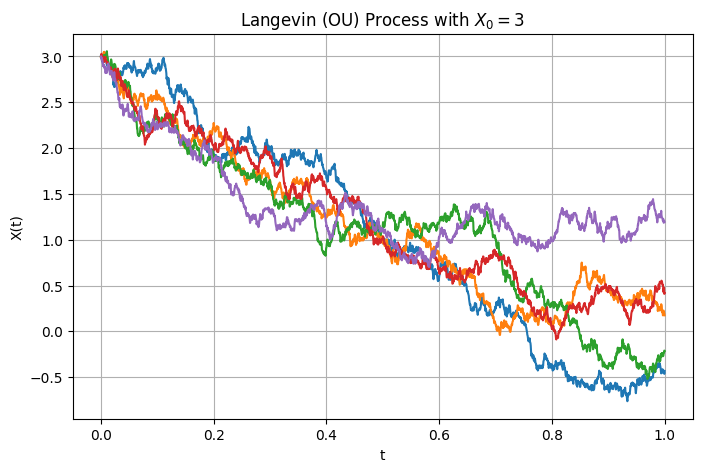

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
lambda_ = 2
sigma = 1.0

T = 1.0
N = 2000
dt = T / N
time = np.linspace(0, T, N+1)

n_paths = 5
X0 = 3.0   # initial condition

# =========================
# Euler–Maruyama simulation
# =========================
def simulate_ou(n_paths, N, dt, lambda_, sigma, X0):
    X = np.zeros((n_paths, N+1))
    X[:, 0] = X0   # set initial value

    for k in range(N):
        dW = np.sqrt(dt) * np.random.randn(n_paths)
        X[:, k+1] = X[:, k] - lambda_ * X[:, k] * dt + sigma * dW

    return X

# simulate paths
X_paths = simulate_ou(n_paths, N, dt, lambda_, sigma, X0)

# =========================
# Plot realizations
# =========================
plt.figure(figsize=(8,5))
for i in range(n_paths):
    plt.plot(time, X_paths[i], lw=1.5)

plt.title("Langevin (OU) Process with $X_0 = 3$")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

**Exact discretization formula**

We simulate an OU process with $\lambda =2$ and $\sigma =1$, using $X_0=3$ and $3,000$ discretisation steps.

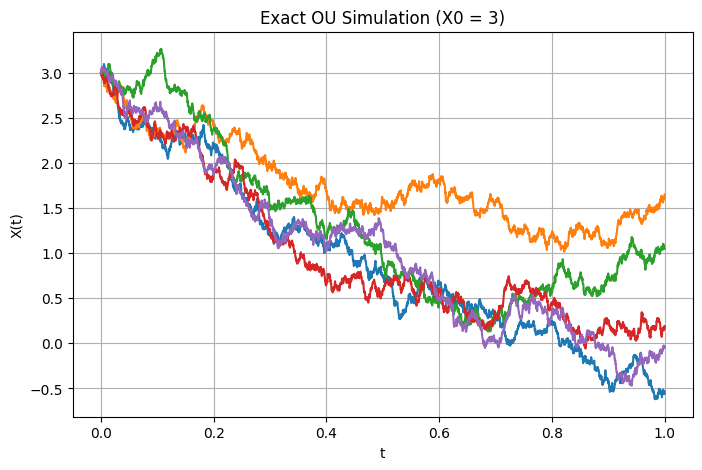

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lambda_ = 2
sigma = 1.0

T = 1.0
N = 3000
dt = T / N
time = np.linspace(0, T, N+1)

n_paths = 5
X0 = 3.0

phi = np.exp(-lambda_ * dt)
sigma_eps = np.sqrt((sigma**2 / (2*lambda_)) * (1 - phi**2))

X = np.zeros((n_paths, N+1))
X[:,0] = X0

for k in range(N):
    noise = sigma_eps * np.random.randn(n_paths)
    X[:,k+1] = phi * X[:,k] + noise

# Plot
plt.figure(figsize=(8,5))
for i in range(n_paths):
    plt.plot(time, X[i])

plt.title("Exact OU Simulation (X0 = 3)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.show()

**1. Quantile matching method**

Epoch 0: loss=3.44314, lambda=0.5005, sigma=1.0005
Epoch 200: loss=2.53721, lambda=0.5952, sigma=1.0976
Epoch 400: loss=1.95608, lambda=0.6795, sigma=1.1862
Epoch 600: loss=1.56430, lambda=0.7559, sigma=1.2668
Epoch 800: loss=1.28859, lambda=0.8265, sigma=1.3396
Epoch 1000: loss=1.08873, lambda=0.8922, sigma=1.4049
Epoch 1200: loss=0.93978, lambda=0.9542, sigma=1.4628
Epoch 1400: loss=0.82532, lambda=1.0133, sigma=1.5132
Epoch 1600: loss=0.73421, lambda=1.0706, sigma=1.5559
Epoch 1800: loss=0.65988, lambda=1.1264, sigma=1.5907
Epoch 2000: loss=0.59764, lambda=1.1813, sigma=1.6170
Epoch 2200: loss=0.54430, lambda=1.2353, sigma=1.6344
Epoch 2400: loss=0.49729, lambda=1.2888, sigma=1.6425
Epoch 2600: loss=0.45464, lambda=1.3420, sigma=1.6407
Epoch 2800: loss=0.41460, lambda=1.3951, sigma=1.6287
Epoch 3000: loss=0.37597, lambda=1.4484, sigma=1.6062
Epoch 3200: loss=0.33772, lambda=1.5020, sigma=1.5732
Epoch 3400: loss=0.29918, lambda=1.5559, sigma=1.5301
Epoch 3600: loss=0.26004, lambda=1.

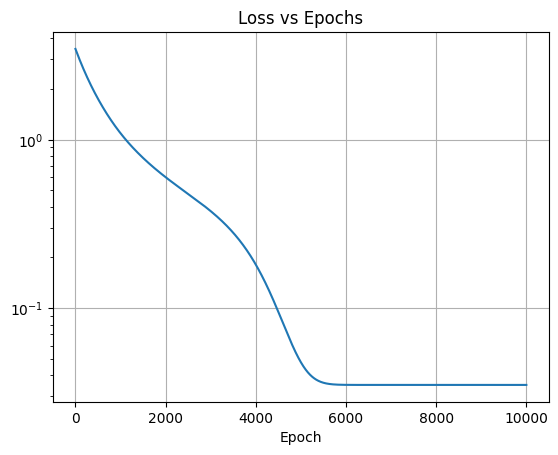

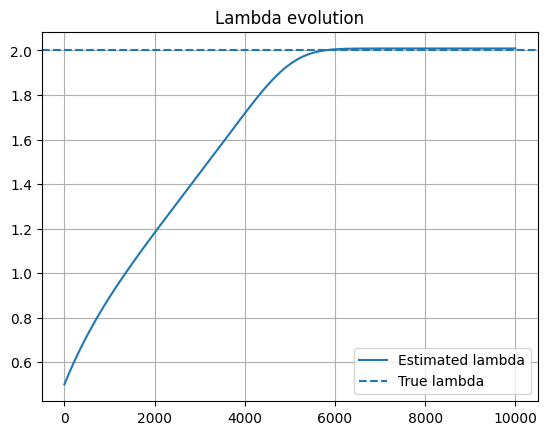

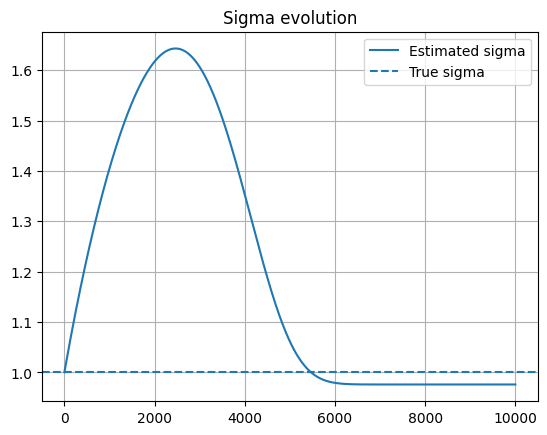

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import norm

# =========================
# 1. True parameters
# =========================
lambda_true = 2.0
sigma_true = 1.0
X0 = 3.0

T = 1.0
N_total = 3000
dt = T / N_total

# =========================
# 2. Exact OU simulation
# =========================
phi = np.exp(-lambda_true * dt)
sigma_eps = np.sqrt((sigma_true**2 / (2*lambda_true)) * (1 - phi**2))

X = np.zeros(N_total + 1)
X[0] = X0

for k in range(N_total):
    X[k+1] = phi * X[k] + sigma_eps * np.random.randn()

# =========================
# 3. Subsample N=200
# =========================
N = 200
indices = np.linspace(0, N_total, N).astype(int)

t_data = indices * dt
X_data = X[indices]

t_tf = tf.constant(t_data.reshape(-1,1), dtype=tf.float32)
X_tf = tf.constant(X_data.reshape(-1,1), dtype=tf.float32)

# =========================
# 4. Quantile targets
# =========================
Q = 100
u = (np.arange(1, Q+1) - 0.5) / Q
q_star = norm.ppf(u)

u_tf = tf.constant(u.reshape(-1,1), dtype=tf.float32)
q_star_tf = tf.constant(q_star.reshape(-1,1), dtype=tf.float32)

# =========================
# 5. Trainable parameters
# =========================
lambda_var = tf.Variable(0.5, dtype=tf.float32)
r_var = tf.Variable(0.0, dtype=tf.float32)   # sigma = exp(r)

optimizer = tf.keras.optimizers.Adam(5e-4)

# =========================
# 6. Soft quantile function (FIXED)
# =========================
def soft_quantiles(Z, alpha=100.0):
    Z_sorted = tf.sort(Z, axis=0)            # (N,1)

    Nloc = tf.shape(Z_sorted)[0]
    ranks = tf.cast(tf.range(1, Nloc+1), tf.float32) / tf.cast(Nloc, tf.float32)
    ranks = tf.reshape(ranks, (-1,1))        # (N,1)

    # Expand for broadcasting
    ranks_exp = tf.expand_dims(ranks, axis=1)   # (N,1,1)
    u_exp = tf.expand_dims(u_tf, axis=0)        # (1,Q,1)

    dist = tf.abs(ranks_exp - u_exp)            # (N,Q,1)

    weights = tf.nn.softmax(-alpha * dist, axis=0)

    Z_exp = tf.expand_dims(Z_sorted, axis=1)    # (N,1,1)

    q = tf.reduce_sum(weights * Z_exp, axis=0)  # (Q,1)

    return q

# =========================
# 7. Training
# =========================
epochs = 10000

loss_hist = []
lambda_hist = []
sigma_hist = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:

        sigma = tf.exp(r_var)

        # Mean and variance
        mu = X0 * tf.exp(-lambda_var * t_tf)

        var = (sigma**2 / (2*lambda_var)) * (1 - tf.exp(-2*lambda_var * t_tf))
        std = tf.sqrt(var + 1e-6)

        Z = (X_tf - mu) / std

        q_pred = soft_quantiles(Z)

        loss = tf.reduce_mean((q_pred - q_star_tf)**2)

    grads = tape.gradient(loss, [lambda_var, r_var])
    optimizer.apply_gradients(zip(grads, [lambda_var, r_var]))

    loss_hist.append(loss.numpy())
    lambda_hist.append(lambda_var.numpy())
    sigma_hist.append(np.exp(r_var.numpy()))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: loss={loss.numpy():.5f}, "
              f"lambda={lambda_var.numpy():.4f}, sigma={np.exp(r_var.numpy()):.4f}")

# =========================
# 8. Plot loss
# =========================
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Loss vs Epochs")
plt.xlabel("Epoch")
plt.grid()
plt.show()

# =========================
# 9. Plot lambda
# =========================
plt.figure()
plt.plot(lambda_hist, label="Estimated lambda")
plt.axhline(lambda_true, linestyle='--', label="True lambda")
plt.legend()
plt.title("Lambda evolution")
plt.grid()
plt.show()

# =========================
# 10. Plot sigma
# =========================
plt.figure()
plt.plot(sigma_hist, label="Estimated sigma")
plt.axhline(sigma_true, linestyle='--', label="True sigma")
plt.legend()
plt.title("Sigma evolution")
plt.grid()
plt.show()

**Moment Matching**

Epoch 0: loss=0.90001, lambda=1.0010, sigma=0.9990
Epoch 200: loss=0.13614, lambda=1.3102, sigma=0.8102
Epoch 400: loss=0.02194, lambda=1.2462, sigma=0.7355
Epoch 600: loss=0.00113, lambda=1.2035, sigma=0.7054
Epoch 800: loss=0.00092, lambda=1.1994, sigma=0.7027
Epoch 1000: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 1200: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 1400: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 1600: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 1800: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 2000: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 2200: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 2400: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 2600: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 2800: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 3000: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 3200: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 3400: loss=0.00092, lambda=1.1993, sigma=0.7026
Epoch 3600: loss=0.00092, lambda=1.

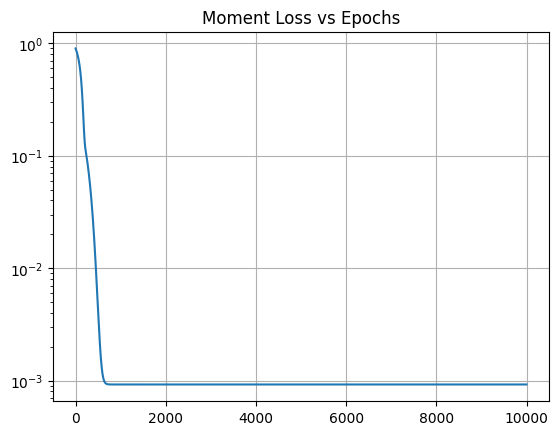

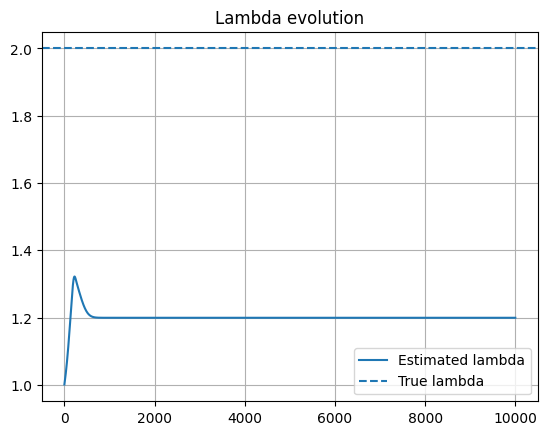

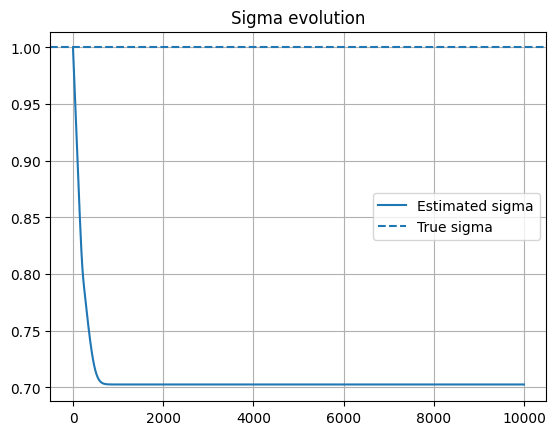

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# =========================
# 1. True parameters
# =========================
lambda_true = 2.0
sigma_true = 1.0
X0 = 3.0

T = 1.0
N_total = 3000
dt = T / N_total

# =========================
# 2. Exact OU simulation
# =========================
phi = np.exp(-lambda_true * dt)
sigma_eps = np.sqrt((sigma_true**2 / (2*lambda_true)) * (1 - phi**2))

X = np.zeros(N_total + 1)
X[0] = X0

for k in range(N_total):
    X[k+1] = phi * X[k] + sigma_eps * np.random.randn()

# =========================
# 3. Subsample N=200
# =========================
N = 200
indices = np.linspace(0, N_total, N).astype(int)

t_data = indices * dt
X_data = X[indices]

t_tf = tf.constant(t_data.reshape(-1,1), dtype=tf.float32)
X_tf = tf.constant(X_data.reshape(-1,1), dtype=tf.float32)

# =========================
# 4. Trainable parameters
# =========================
r_var = tf.Variable(np.log(1.0), dtype=tf.float32)  # lambda = exp(r)
u_var = tf.Variable(np.log(1.0), dtype=tf.float32)  # sigma = exp(u)

optimizer = tf.keras.optimizers.Adam(1e-3)

# =========================
# 5. Training
# =========================
epochs = 10000

loss_hist = []
lambda_hist = []
sigma_hist = []

for epoch in range(epochs):
    with tf.GradientTape() as tape:

        lambda_var = tf.exp(r_var)
        sigma = tf.exp(u_var)

        # Mean and variance
        mu = X0 * tf.exp(-lambda_var * t_tf)

        var = (sigma**2 / (2*lambda_var)) * (1 - tf.exp(-2*lambda_var * t_tf))
        std = tf.sqrt(var + 1e-8)

        # Standardized data
        Z = (X_tf - mu) / std

        # Empirical moments
        m1 = tf.reduce_mean(Z)
        m2 = tf.reduce_mean(Z**2)
        m3 = tf.reduce_mean(Z**3)
        m4 = tf.reduce_mean(Z**4)
        m5 = tf.reduce_mean(Z**5)
        m6 = tf.reduce_mean(Z**6)
        m7 = tf.reduce_mean(Z**7)

        # Moment matching loss
        loss = (
            m1**2
            + 0.1*m3**2
            + 0*m5**2
            + (m2 - 1.0)**2
            + 0.1*(m4 - 3.0)**2
            + 0.0*(m6 - 15.0)**2
            +0.0*m7**2
        )

    grads = tape.gradient(loss, [r_var, u_var])
    optimizer.apply_gradients(zip(grads, [r_var, u_var]))

    loss_hist.append(loss.numpy())
    lambda_hist.append(np.exp(r_var.numpy()))
    sigma_hist.append(np.exp(u_var.numpy()))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: loss={loss.numpy():.5f}, "
              f"lambda={np.exp(r_var.numpy()):.4f}, sigma={np.exp(u_var.numpy()):.4f}")

# =========================
# 6. Plot loss
# =========================
plt.figure()
plt.plot(loss_hist)
plt.yscale('log')
plt.title("Moment Loss vs Epochs")
plt.grid()
plt.show()

# =========================
# 7. Plot lambda
# =========================
plt.figure()
plt.plot(lambda_hist, label="Estimated lambda")
plt.axhline(lambda_true, linestyle='--', label="True lambda")
plt.legend()
plt.title("Lambda evolution")
plt.grid()
plt.show()

# =========================
# 8. Plot sigma
# =========================
plt.figure()
plt.plot(sigma_hist, label="Estimated sigma")
plt.axhline(sigma_true, linestyle='--', label="True sigma")
plt.legend()
plt.title("Sigma evolution")
plt.grid()
plt.show()

**$AR(1)$-model method**

True parameters:
lambda = 2.0, sigma = 1.0

Estimated parameters:
phi_hat     = 0.99047
lambda_hat  = 1.91525
sigma_hat   = 0.99442


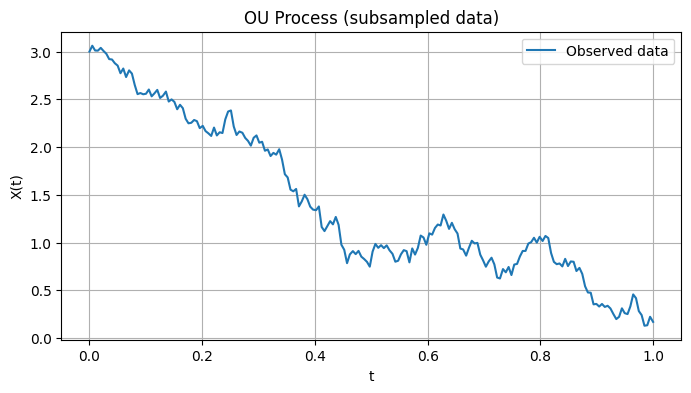

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. True parameters
# =========================
lambda_true = 2.0
sigma_true = 1.0
X0 = 3.0

T = 1.0
N_total = 3000
dt = T / N_total

# =========================
# 2. Exact OU simulation
# =========================
phi_true = np.exp(-lambda_true * dt)
sigma_eps_true = np.sqrt((sigma_true**2 / (2*lambda_true)) * (1 - phi_true**2))

X = np.zeros(N_total + 1)
X[0] = X0

for k in range(N_total):
    X[k+1] = phi_true * X[k] + sigma_eps_true * np.random.randn()

# =========================
# 3. Subsample N=200 points
# =========================
N = 200
indices = np.linspace(0, N_total, N).astype(int)

X_data = X[indices]
t_data = indices * dt

# =========================
# 4. AR(1) estimation
# =========================
X_i = X_data[:-1]
X_ip1 = X_data[1:]

# ---- estimate phi
phi_hat = np.sum(X_i * X_ip1) / np.sum(X_i**2)

# ---- estimate lambda
Delta_t = t_data[1] - t_data[0]
lambda_hat = -np.log(phi_hat) / Delta_t

# ---- residuals
epsilon_hat = X_ip1 - phi_hat * X_i

# ---- residual variance
sigma_eps_hat = np.mean(epsilon_hat**2)

# ---- estimate sigma
sigma_hat = np.sqrt((2 * lambda_hat * sigma_eps_hat) / (1 - phi_hat**2))

# =========================
# 5. Print results
# =========================
print("True parameters:")
print(f"lambda = {lambda_true}, sigma = {sigma_true}")

print("\nEstimated parameters:")
print(f"phi_hat     = {phi_hat:.5f}")
print(f"lambda_hat  = {lambda_hat:.5f}")
print(f"sigma_hat   = {sigma_hat:.5f}")

# =========================
# 6. Plot sample path
# =========================
plt.figure(figsize=(8,4))
plt.plot(t_data, X_data, label="Observed data")
plt.title("OU Process (subsampled data)")
plt.xlabel("t")
plt.ylabel("X(t)")
plt.grid()
plt.legend()
plt.show()

**AR(1)-model, multiple simulations and histogram constructions forestimators.**

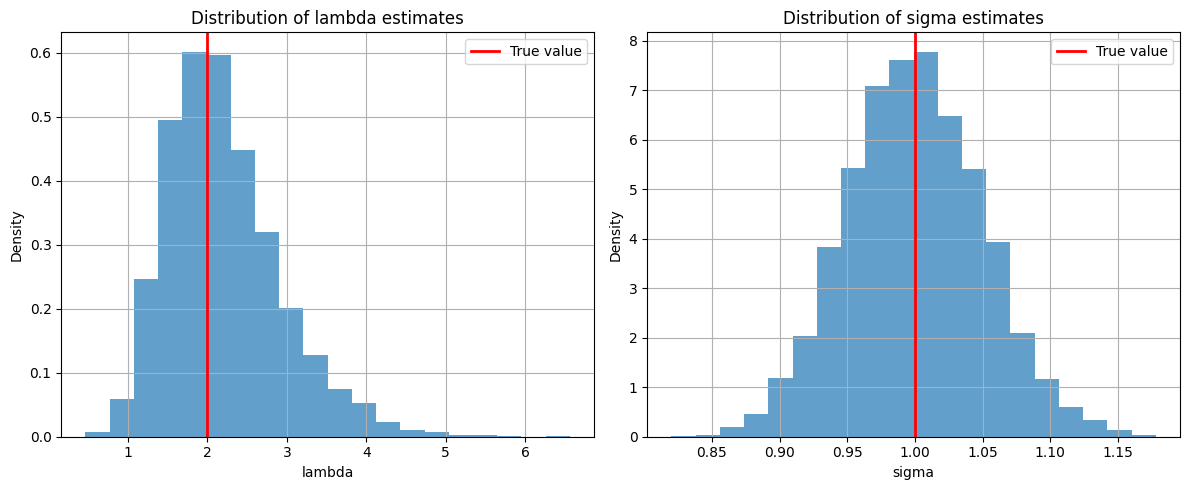

Lambda: mean = 2.203925393482229 std = 0.7202825124231057
Sigma:  mean = 0.9998183904160445 std = 0.05023711997124342


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# True parameters
# =========================
lambda_true = 2.0
sigma_true = 1.0
X0 = 3.0

T = 1.0
N_total = 3000
dt = T / N_total

# subsampling
N = 200

# Monte Carlo runs
M = 10000

lambda_estimates = []
sigma_estimates = []

for m in range(M):

    # =========================
    # Simulate OU (exact)
    # =========================
    phi_true = np.exp(-lambda_true * dt)
    sigma_eps_true = np.sqrt((sigma_true**2 / (2*lambda_true)) * (1 - phi_true**2))

    X = np.zeros(N_total + 1)
    X[0] = X0

    for k in range(N_total):
        X[k+1] = phi_true * X[k] + sigma_eps_true * np.random.randn()

    # =========================
    # Subsample N=200
    # =========================
    indices = np.linspace(0, N_total, N).astype(int)

    X_data = X[indices]
    t_data = indices * dt

    X_i = X_data[:-1]
    X_ip1 = X_data[1:]

    # =========================
    # Estimate phi
    # =========================
    phi_hat = np.sum(X_i * X_ip1) / np.sum(X_i**2)

    # numerical safety
    if phi_hat <= 0:
        continue

    # =========================
    # Estimate lambda
    # =========================
    Delta_t = t_data[1] - t_data[0]
    lambda_hat = -np.log(phi_hat) / Delta_t

    # =========================
    # Residuals
    # =========================
    epsilon_hat = X_ip1 - phi_hat * X_i
    sigma_eps_hat = np.mean(epsilon_hat**2)

    # =========================
    # Estimate sigma
    # =========================
    sigma_hat = np.sqrt((2 * lambda_hat * sigma_eps_hat) / (1 - phi_hat**2))

    lambda_estimates.append(lambda_hat)
    sigma_estimates.append(sigma_hat)

lambda_estimates = np.array(lambda_estimates)
sigma_estimates = np.array(sigma_estimates)

# =========================
# Plot histograms
# =========================
plt.figure(figsize=(12,5))

# ---- Lambda histogram
plt.subplot(1,2,1)
plt.hist(lambda_estimates, bins=20, density=True, alpha=0.7)
plt.axvline(lambda_true, color='red', linewidth=2, label="True value")
plt.title("Distribution of lambda estimates")
plt.xlabel("lambda")
plt.ylabel("Density")
plt.legend()
plt.grid()

# ---- Sigma histogram
plt.subplot(1,2,2)
plt.hist(sigma_estimates, bins=20, density=True, alpha=0.7)
plt.axvline(sigma_true, color='red', linewidth=2, label="True value")
plt.title("Distribution of sigma estimates")
plt.xlabel("sigma")
plt.ylabel("Density")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# =========================
# Print summary
# =========================
print("Lambda: mean =", np.mean(lambda_estimates), "std =", np.std(lambda_estimates))
print("Sigma:  mean =", np.mean(sigma_estimates),  "std =", np.std(sigma_estimates))